# Product Portfolio - SKU Rationalization

Last update: 20h30 26/4/2026 hungkhuu404

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root(start=Path.cwd()):
    """Find VinDatathon project root from the active notebook working directory."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == "VinDatathon_the-4-Outliers" and (candidate / "data" / "clean").exists():
            return candidate
        child = candidate / "VinDatathon_the-4-Outliers"
        if (child / "data" / "clean").exists():
            return child.resolve()
    raise FileNotFoundError("Cannot find VinDatathon_the-4-Outliers/data/clean from Path.cwd().")


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "clean"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from theme import (  # noqa: E402
    apply_theme,
    style_ax,
    COLORS,
    CATEGORICAL,
    CLR_LABEL,
    CLR_MUTED,
    CLR_TITLE,
    colors_for,
    get_palette,
)

apply_theme()

TABLES = {
    "order_items": "order_items.parquet",
    "orders": "orders.parquet",
    "products": "products.parquet",
    "returns": "returns.parquet",
    "reviews": "reviews.parquet",
    "inventory": "inventory.parquet",
    "sales": "sales.parquet",
    "payments": "payments.parquet",
}

order_items = pd.read_parquet(DATA_DIR / TABLES["order_items"])
orders = pd.read_parquet(DATA_DIR / TABLES["orders"])
products = pd.read_parquet(DATA_DIR / TABLES["products"])
returns = pd.read_parquet(DATA_DIR / TABLES["returns"])
reviews = pd.read_parquet(DATA_DIR / TABLES["reviews"])
inventory = pd.read_parquet(DATA_DIR / TABLES["inventory"])
sales = pd.read_parquet(DATA_DIR / TABLES["sales"])
payments = pd.read_parquet(DATA_DIR / TABLES["payments"])


def fmt_vnd_m(value):
    return f"{value / 1e6:,.1f}M VND"


def fmt_vnd_b(value):
    return f"{value / 1e9:,.3f}B VND"


def fmt_pct(value, digits=2):
    return f"{value * 100:,.{digits}f}%"


def safe_divide(num, den):
    return np.divide(num, den, out=np.full_like(np.asarray(num, dtype="float64"), np.nan), where=np.asarray(den) != 0)

load_summary = pd.DataFrame(
    [{"table": name, "rows": len(globals()[name]), "columns": globals()[name].shape[1]} for name in TABLES]
)

print(f"Project root: {ROOT.name}")
print(f"Output dir:   {OUTPUT_DIR.relative_to(ROOT)}")
display(load_summary)

Vivid Slate theme applied.


Project root: VinDatathon_the-4-Outliers
Output dir:   outputs


,table,rows,columns
0,order_items,714669,7
1,orders,646945,8
2,products,2412,8
3,returns,39939,7
4,reviews,113551,7
5,inventory,60247,17
6,sales,3833,3
7,payments,646945,4


In [2]:
# Reconciliation uses all order statuses because sales.Revenue and sales.COGS are booked targets.
line_recon = order_items.merge(products[["product_id", "cogs"]], on="product_id", how="left").copy()
line_recon["discount_amount"] = line_recon["discount_amount"].fillna(0)
line_recon["line_revenue"] = line_recon["quantity"] * line_recon["unit_price"]
line_recon["net_line"] = line_recon["line_revenue"] - line_recon["discount_amount"]
line_recon["cogs_line"] = line_recon["quantity"] * line_recon["cogs"]

reconciliation = pd.DataFrame(
    [
        {
            "check": "sum(quantity * unit_price) vs sales.Revenue",
            "computed": line_recon["line_revenue"].sum(),
            "target": sales["Revenue"].sum(),
            "basis": "all order statuses",
        },
        {
            "check": "sum(net_line) vs payments.payment_value",
            "computed": line_recon["net_line"].sum(),
            "target": payments["payment_value"].sum(),
            "basis": "all order statuses, after discount",
        },
        {
            "check": "sum(quantity * cogs) vs sales.COGS",
            "computed": line_recon["cogs_line"].sum(),
            "target": sales["COGS"].sum(),
            "basis": "all order statuses",
        },
    ]
)
reconciliation["diff"] = reconciliation["computed"] - reconciliation["target"]
reconciliation["abs_diff"] = reconciliation["diff"].abs()

display(
    reconciliation.assign(
        computed=lambda d: d["computed"].map(lambda x: f"{x:,.2f}"),
        target=lambda d: d["target"].map(lambda x: f"{x:,.2f}"),
        diff=lambda d: d["diff"].map(lambda x: f"{x:,.6f}"),
        abs_diff=lambda d: d["abs_diff"].map(lambda x: f"{x:,.6f}"),
    )
)

assert np.isclose(line_recon["line_revenue"].sum(), sales["Revenue"].sum(), atol=1e-2)
assert np.isclose(line_recon["net_line"].sum(), payments["payment_value"].sum(), atol=1e-2)
assert np.isclose(line_recon["cogs_line"].sum(), sales["COGS"].sum(), atol=1e-2)

,check,computed,target,basis,diff,abs_diff
0,sum(quantity * unit_price) vs sales.Revenue,"16,430,476,585.53","16,430,476,585.53",all order statuses,0.000004,0.000004
1,sum(net_line) vs payments.payment_value,"15,680,869,265.43","15,680,869,265.43","all order statuses, after discount",0.000000,0.000000
2,sum(quantity * cogs) vs sales.COGS,"14,163,450,519.13","14,163,450,519.17",all order statuses,-0.042133,0.042133


In [3]:
# CELL 1A — Revenue Lineage / Refund Reconciliation
# This cell backs the report opening: gross booked revenue, discount burn,
# refund leakage, and realized-cash proxy are intentionally kept as separate bases.
gross_booked = sales["Revenue"].sum()
discount_burn = line_recon["discount_amount"].sum()
net_paid = payments["payment_value"].sum()
refund_total = returns["refund_amount"].sum()
realized_cash_proxy = gross_booked - discount_burn - refund_total

lineage = pd.DataFrame(
    [
        {
            "metric": "Gross booked revenue",
            "value": gross_booked,
            "report_value": f"{gross_booked / 1e9:.2f}B VND",
            "basis": "sales.Revenue / all order statuses",
        },
        {
            "metric": "Discount burn",
            "value": discount_burn,
            "report_value": f"{discount_burn / 1e6:.1f}M VND",
            "basis": "sum(order_items.discount_amount)",
        },
        {
            "metric": "Net paid after discount",
            "value": net_paid,
            "report_value": f"{net_paid / 1e9:.2f}B VND",
            "basis": "payments.payment_value",
        },
        {
            "metric": "Refund leakage pool",
            "value": refund_total,
            "report_value": f"{refund_total / 1e6:.1f}M VND",
            "basis": "sum(returns.refund_amount), historical 2012-2022",
        },
        {
            "metric": "Realized-cash proxy",
            "value": realized_cash_proxy,
            "report_value": f"{realized_cash_proxy / 1e9:.2f}B VND",
            "basis": "gross booked - discount burn - refund leakage; proxy, not audited P&L",
        },
    ]
)

display(lineage[["metric", "report_value", "basis"]])
assert abs(gross_booked - discount_burn - net_paid) < 1_000
print(
    f"Report opening check: gross {gross_booked / 1e9:.2f}B, "
    f"discount {discount_burn / 1e6:.1f}M, refund {refund_total / 1e6:.1f}M, "
    f"realized-cash proxy {realized_cash_proxy / 1e9:.2f}B VND."
)

,metric,report_value,basis
0,Gross booked revenue,16.43B VND,sales.Revenue / all order statuses
1,Discount burn,749.6M VND,sum(order_items.discount_amount)
2,Net paid after discount,15.68B VND,payments.payment_value
3,Refund leakage pool,510.6M VND,"sum(returns.refund_amount), historical 2012-2022"
4,Realized-cash proxy,15.17B VND,gross booked - discount burn - refund leakage;...


Report opening check: gross 16.43B, discount 749.6M, refund 510.6M, realized-cash proxy 15.17B VND.


In [4]:
FULFILLED_EXCLUDE = ["cancelled", "created"]
PRODUCT_COLS = ["product_id", "product_name", "category", "segment", "size", "color", "price", "cogs"]

# One canonical line-item fact table. All profitability analysis below uses fulfilled lines only.
oi = (
    order_items.merge(
        orders[["order_id", "order_date", "customer_id", "order_status"]],
        on="order_id",
        how="left",
        validate="many_to_one",
    )
    .merge(products[PRODUCT_COLS], on="product_id", how="left", validate="many_to_one")
    .copy()
)

oi["discount_amount"] = oi["discount_amount"].fillna(0)
oi["line_revenue"] = oi["quantity"] * oi["unit_price"]
oi["net_line"] = oi["line_revenue"] - oi["discount_amount"]
oi["cogs_line"] = oi["quantity"] * oi["cogs"]
oi["net_gp"] = oi["net_line"] - oi["cogs_line"]
oi["is_fulfilled"] = ~oi["order_status"].isin(FULFILLED_EXCLUDE)

f = oi.loc[oi["is_fulfilled"]].copy()

sku_tx = (
    f.groupby("product_id", as_index=False)
    .agg(
        fulfilled_volume=("quantity", "sum"),
        order_lines=("order_id", "count"),
        net_sales=("net_line", "sum"),
        cogs_line=("cogs_line", "sum"),
        net_gp=("net_gp", "sum"),
    )
)

sku_master = products[PRODUCT_COLS].merge(sku_tx, on="product_id", how="left")
for col in ["fulfilled_volume", "order_lines", "net_sales", "cogs_line", "net_gp"]:
    sku_master[col] = sku_master[col].fillna(0)

sku_master["net_margin_pct"] = np.where(
    sku_master["net_sales"] > 0,
    sku_master["net_gp"] / sku_master["net_sales"],
    np.nan,
)
sku_master["is_active_order_item"] = sku_master["product_id"].isin(order_items["product_id"])
sku_master["is_active_fulfilled"] = sku_master["fulfilled_volume"] > 0

active_min_price = products.loc[products["product_id"].isin(order_items["product_id"]), "price"].min()
ghost_fake_threshold = 0.75 * active_min_price
sku_master["ghost_status"] = np.select(
    [
        sku_master["is_active_order_item"],
        (~sku_master["is_active_order_item"]) & (sku_master["price"] < ghost_fake_threshold),
        (~sku_master["is_active_order_item"]) & (sku_master["price"] >= ghost_fake_threshold),
    ],
    ["active", "ghost_fake", "ghost_real"],
    default="unknown",
)

returns_enriched = (
    returns.merge(orders[["order_id", "order_status"]], on="order_id", how="left", validate="many_to_one")
    .merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left", validate="many_to_one")
    .copy()
)
returns_enriched["is_fulfilled_order"] = ~returns_enriched["order_status"].isin(FULFILLED_EXCLUDE)
returns_fulfilled = returns_enriched.loc[returns_enriched["is_fulfilled_order"]].copy()

# Aggregate return metrics per SKU.
# Two-pass approach: pass 1 aggregates row-level counts; pass 2 aggregates wrong_size subset
# separately. This avoids cross-column outer-scope references inside agg lambdas, which are
# fragile if returns_fulfilled is ever reset-indexed or reassigned above this cell.
sku_return = (
    returns_fulfilled.groupby("product_id", as_index=False)
    .agg(
        return_rows=("return_id", "count"),
        return_qty=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        wrong_size_rows=("return_reason", lambda s: s.eq("wrong_size").sum()),
    )
)
_ws = (
    returns_fulfilled[returns_fulfilled["return_reason"].eq("wrong_size")]
    .groupby("product_id", as_index=False)
    .agg(wrong_size_qty=("return_quantity", "sum"), wrong_size_refund=("refund_amount", "sum"))
)
sku_return = sku_return.merge(_ws, on="product_id", how="left")
sku_return[["wrong_size_qty", "wrong_size_refund"]] = (
    sku_return[["wrong_size_qty", "wrong_size_refund"]].fillna(0)
)

sku_master = sku_master.merge(sku_return, on="product_id", how="left")
for col in ["return_rows", "return_qty", "refund_amount", "wrong_size_rows", "wrong_size_qty", "wrong_size_refund"]:
    sku_master[col] = sku_master[col].fillna(0)

sku_master["return_qty_rate"] = np.where(
    sku_master["fulfilled_volume"] > 0,
    sku_master["return_qty"] / sku_master["fulfilled_volume"],
    np.nan,
)
sku_master["wrong_size_row_share"] = np.where(
    sku_master["return_rows"] > 0,
    sku_master["wrong_size_rows"] / sku_master["return_rows"],
    np.nan,
)

sku_active = sku_master.loc[sku_master["is_active_fulfilled"]].copy()
median_volume = sku_active["fulfilled_volume"].median()
sku_master["quarantine_candidate"] = (
    sku_master["is_active_fulfilled"]
    & (sku_master["fulfilled_volume"] < median_volume)
    & (sku_master["net_gp"] < 0)
)

inventory_efficiency = (
    inventory.merge(products[["product_id", "price", "cogs"]], on="product_id", how="left", validate="many_to_one")
    .groupby("product_id", as_index=False)
    .agg(
        avg_stock_on_hand=("stock_on_hand", "mean"),
        avg_sell_through_rate=("sell_through_rate", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        overstock_months=("overstock_flag", "sum"),
        cogs=("cogs", "first"),
    )
)
inventory_efficiency["locked_capital"] = inventory_efficiency["avg_stock_on_hand"] * inventory_efficiency["cogs"]
inventory_efficiency = inventory_efficiency.merge(
    products[["product_id", "product_name", "category", "segment", "size"]], on="product_id", how="left"
)

fact_summary = pd.DataFrame(
    [
        {"fact": "oi", "rows": len(oi), "basis": "all order-item lines"},
        {"fact": "f", "rows": len(f), "basis": "fulfilled lines: order_status not in cancelled/created"},
        {"fact": "sku_master", "rows": len(sku_master), "basis": "2,412 master products, fulfilled metrics left-joined"},
        {"fact": "sku_active", "rows": len(sku_active), "basis": "active fulfilled SKUs only"},
        {"fact": "inventory_efficiency", "rows": len(inventory_efficiency), "basis": "avg_stock_on_hand * product cogs"},
    ]
)
display(fact_summary)


,fact,rows,basis
0,oi,714669,all order-item lines
1,f,641002,fulfilled lines: order_status not in cancelled...
2,sku_master,2412,"2,412 master products, fulfilled metrics left-..."
3,sku_active,1581,active fulfilled SKUs only
4,inventory_efficiency,1624,avg_stock_on_hand * product cogs


In [5]:
master_skus = products["product_id"].nunique()
active_skus = order_items["product_id"].nunique()
active_fulfilled_skus = sku_active["product_id"].nunique()
ghost_counts = sku_master["ghost_status"].value_counts()

total_net_sales = f["net_line"].sum()
total_cogs = f["cogs_line"].sum()
total_net_gp = f["net_gp"].sum()
total_net_margin = total_net_gp / total_net_sales

category_perf = (
    f.groupby("category", as_index=False)
    .agg(net_sales=("net_line", "sum"), cogs=("cogs_line", "sum"), net_gp=("net_gp", "sum"))
    .assign(
        net_sales_share=lambda d: d["net_sales"] / total_net_sales,
        net_margin_pct=lambda d: d["net_gp"] / d["net_sales"],
    )
    .sort_values("net_sales", ascending=False)
)

fulfilled_order_ids = set(orders.loc[~orders["order_status"].isin(FULFILLED_EXCLUDE), "order_id"])
returned_fulfilled_order_ids = set(returns["order_id"]) & fulfilled_order_ids
return_rate_order_fulfilled = len(returned_fulfilled_order_ids) / len(fulfilled_order_ids)

return_reason = (
    returns_fulfilled.groupby("return_reason", as_index=False)
    .agg(return_rows=("return_id", "count"), return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
    .assign(row_share=lambda d: d["return_rows"] / d["return_rows"].sum(), refund_share=lambda d: d["refund_amount"] / d["refund_amount"].sum())
    .sort_values("refund_amount", ascending=False)
)
wrong_size_row = return_reason.loc[return_reason["return_reason"].eq("wrong_size")].iloc[0]

size_order = ["S", "M", "L", "XL"]
fulfilled_qty_by_size = f.groupby("size")["quantity"].sum()
size_diag = (
    returns_fulfilled.groupby("size")
    .apply(
        lambda g: pd.Series(
            {
                "return_rows": len(g),
                "return_qty": g["return_quantity"].sum(),
                "wrong_size_rows": g["return_reason"].eq("wrong_size").sum(),
                "wrong_size_qty": g.loc[g["return_reason"].eq("wrong_size"), "return_quantity"].sum(),
                "wrong_size_refund": g.loc[g["return_reason"].eq("wrong_size"), "refund_amount"].sum(),
            }
        )
    )
    .join(fulfilled_qty_by_size.rename("fulfilled_qty"))
)
size_diag["return_qty_rate"] = size_diag["return_qty"] / size_diag["fulfilled_qty"]
size_diag["wrong_size_row_share"] = size_diag["wrong_size_rows"] / size_diag["return_rows"]
size_diag["wrong_size_qty_share"] = size_diag["wrong_size_qty"] / size_diag["return_qty"]
size_diag = size_diag.loc[size_order]

negative_skus = sku_master.loc[sku_master["net_gp"] < 0]
quarantine_skus = sku_master.loc[sku_master["quarantine_candidate"]].copy()

sku_pareto = sku_master.sort_values("net_gp", ascending=False).reset_index(drop=True)
sku_pareto["rank"] = np.arange(1, len(sku_pareto) + 1)
sku_pareto["sku_percentile"] = sku_pareto["rank"] / len(sku_pareto)
sku_pareto["cumulative_net_gp"] = sku_pareto["net_gp"].cumsum()
sku_pareto["cumulative_net_gp_share"] = sku_pareto["cumulative_net_gp"] / total_net_gp

top_20_n = int(np.ceil(0.20 * len(sku_master)))
bottom_30_n = int(np.ceil(0.30 * len(sku_master)))
top_20_gp_share = sku_pareto.head(top_20_n)["net_gp"].sum() / total_net_gp
bottom_30_gp_share = sku_pareto.tail(bottom_30_n)["net_gp"].sum() / total_net_gp

streetwear = category_perf.loc[category_perf["category"].eq("Streetwear")].iloc[0]
genz = category_perf.loc[category_perf["category"].eq("GenZ")].iloc[0]

kpi_contract = pd.DataFrame(
    [
        {"metric": "Master SKUs", "value": f"{master_skus:,.0f}", "basis": "products master"},
        {"metric": "Active SKUs in order_items", "value": f"{active_skus:,.0f}", "basis": "order_items product_id"},
        {"metric": "Active fulfilled SKUs", "value": f"{active_fulfilled_skus:,.0f}", "basis": "fulfilled lines only"},
        {"metric": "Ghost SKUs", "value": f"{ghost_counts.get('ghost_fake', 0) + ghost_counts.get('ghost_real', 0):,.0f} = {ghost_counts.get('ghost_fake', 0):,.0f} ghost_fake + {ghost_counts.get('ghost_real', 0):,.0f} ghost_real", "basis": "ghost_fake threshold = 0.75 * active_min_price"},
        {"metric": "Net fulfilled sales", "value": fmt_vnd_b(total_net_sales), "basis": "sum(net_line), fulfilled"},
        {"metric": "Fulfilled COGS", "value": fmt_vnd_b(total_cogs), "basis": "sum(quantity * cogs), fulfilled"},
        {"metric": "Net fulfilled GP", "value": fmt_vnd_b(total_net_gp), "basis": "net_line - cogs_line, fulfilled"},
        {"metric": "Net fulfilled margin", "value": fmt_pct(total_net_margin), "basis": "net GP / net fulfilled sales"},
        {"metric": "Streetwear", "value": f"{fmt_pct(streetwear['net_sales_share'])} sales share, {fmt_pct(streetwear['net_margin_pct'])} margin", "basis": "category on fulfilled lines"},
        {"metric": "GenZ", "value": f"{fmt_pct(genz['net_sales_share'])} sales share, {fmt_pct(genz['net_margin_pct'])} margin", "basis": "category on fulfilled lines"},
        {"metric": "Return rate", "value": fmt_pct(return_rate_order_fulfilled), "basis": "order-level: fulfilled orders with any return / fulfilled orders"},
        {"metric": "wrong_size", "value": f"{wrong_size_row['return_rows']:,.0f} returns, {fmt_pct(wrong_size_row['row_share'])}, {fmt_vnd_m(wrong_size_row['refund_amount'])} refund", "basis": "return_id rows; refund is historical, not annual"},
        {"metric": "Size return quantity rate", "value": f"{size_diag['return_qty_rate'].min()*100:.2f}%\u2013{size_diag['return_qty_rate'].max()*100:.2f}%", "basis": "return_quantity / fulfilled quantity, S/M/L/XL"},
        {"metric": "Wrong-size share by size", "value": f"{size_diag['wrong_size_row_share'].min()*100:.2f}%\u2013{size_diag['wrong_size_row_share'].max()*100:.2f}%", "basis": "wrong_size return rows / return rows, S/M/L/XL"},
        {"metric": "Negative net-GP SKUs", "value": f"{len(negative_skus):,.0f} SKUs, {fmt_vnd_m(-negative_skus['net_gp'].sum())} loss", "basis": "active fulfilled SKUs; net GP < 0"},
        {"metric": "Quarantine candidates", "value": f"{len(quarantine_skus):,.0f} SKUs, {fmt_vnd_m(-quarantine_skus['net_gp'].sum())} loss", "basis": "fulfilled volume < median volume and net GP < 0"},
        {"metric": "SKU GP concentration", "value": f"Top 20% = {fmt_pct(top_20_gp_share, 1)}; bottom 30% = {fmt_pct(bottom_30_gp_share, 1)}", "basis": "master SKU universe, sorted by net GP"},
    ]
)

display(kpi_contract)

inventory_appendix = (
    inventory_efficiency.sort_values("locked_capital", ascending=False)
    .head(10)
    [["product_id", "product_name", "category", "segment", "size", "avg_stock_on_hand", "avg_sell_through_rate", "avg_stockout_days", "locked_capital"]]
    .copy()
)
inventory_appendix["locked_capital"] = inventory_appendix["locked_capital"].map(fmt_vnd_m)
inventory_appendix["avg_stock_on_hand"] = inventory_appendix["avg_stock_on_hand"].map(lambda x: f"{x:,.1f}")
inventory_appendix["avg_sell_through_rate"] = inventory_appendix["avg_sell_through_rate"].map(lambda x: f"{x:.2f}")
inventory_appendix["avg_stockout_days"] = inventory_appendix["avg_stockout_days"].map(lambda x: f"{x:.1f}")

print("Inventory efficiency appendix: locked capital = avg_stock_on_hand * cogs, not sum(stock) * mean(cogs).")
display(inventory_appendix)


,metric,value,basis
0,Master SKUs,"2,412",products master
1,Active SKUs in order_items,"1,598",order_items product_id
2,Active fulfilled SKUs,"1,581",fulfilled lines only
3,Ghost SKUs,814 = 656 ghost_fake + 158 ghost_real,ghost_fake threshold = 0.75 * active_min_price
4,Net fulfilled sales,14.052B VND,"sum(net_line), fulfilled"
5,Fulfilled COGS,12.691B VND,"sum(quantity * cogs), fulfilled"
6,Net fulfilled GP,1.361B VND,"net_line - cogs_line, fulfilled"
7,Net fulfilled margin,9.69%,net GP / net fulfilled sales
8,Streetwear,"80.10% sales share, 9.29% margin",category on fulfilled lines
9,GenZ,"2.10% sales share, 15.41% margin",category on fulfilled lines


Inventory efficiency appendix: locked capital = avg_stock_on_hand * cogs, not sum(stock) * mean(cogs).


,product_id,product_name,category,segment,size,avg_stock_on_hand,avg_sell_through_rate,avg_stockout_days,locked_capital
574,826,HanoiStreet UM-10,Streetwear,Balanced,L,"1,355.3",0.06,0.9,16.4M VND
315,487,SaigonFlex UM-92,Streetwear,Balanced,XL,"1,366.9",0.13,1.1,15.1M VND
334,506,SaigonFlex UM-11,Streetwear,Balanced,L,664.8,0.14,1.0,9.6M VND
305,475,SaigonFlex UM-80,Streetwear,Balanced,XL,885.5,0.12,0.8,8.9M VND
241,396,SaigonFlex UM-01,Streetwear,Balanced,S,846.7,0.11,1.0,8.5M VND
444,635,SaigonFlex UC-00,Streetwear,Everyday,XL,817.1,0.09,0.9,7.5M VND
610,927,HanoiStreet UE-36,Streetwear,Performance,XL,"1,292.7",0.08,1.0,7.2M VND
1410,2054,UrbanVN UE-14,Streetwear,Performance,L,"1,068.1",0.07,1.1,7.2M VND
286,449,SaigonFlex UM-54,Streetwear,Balanced,M,618.2,0.21,1.1,7.0M VND
418,604,SaigonFlex UC-69,Streetwear,Everyday,S,"1,658.2",0.07,1.0,6.9M VND


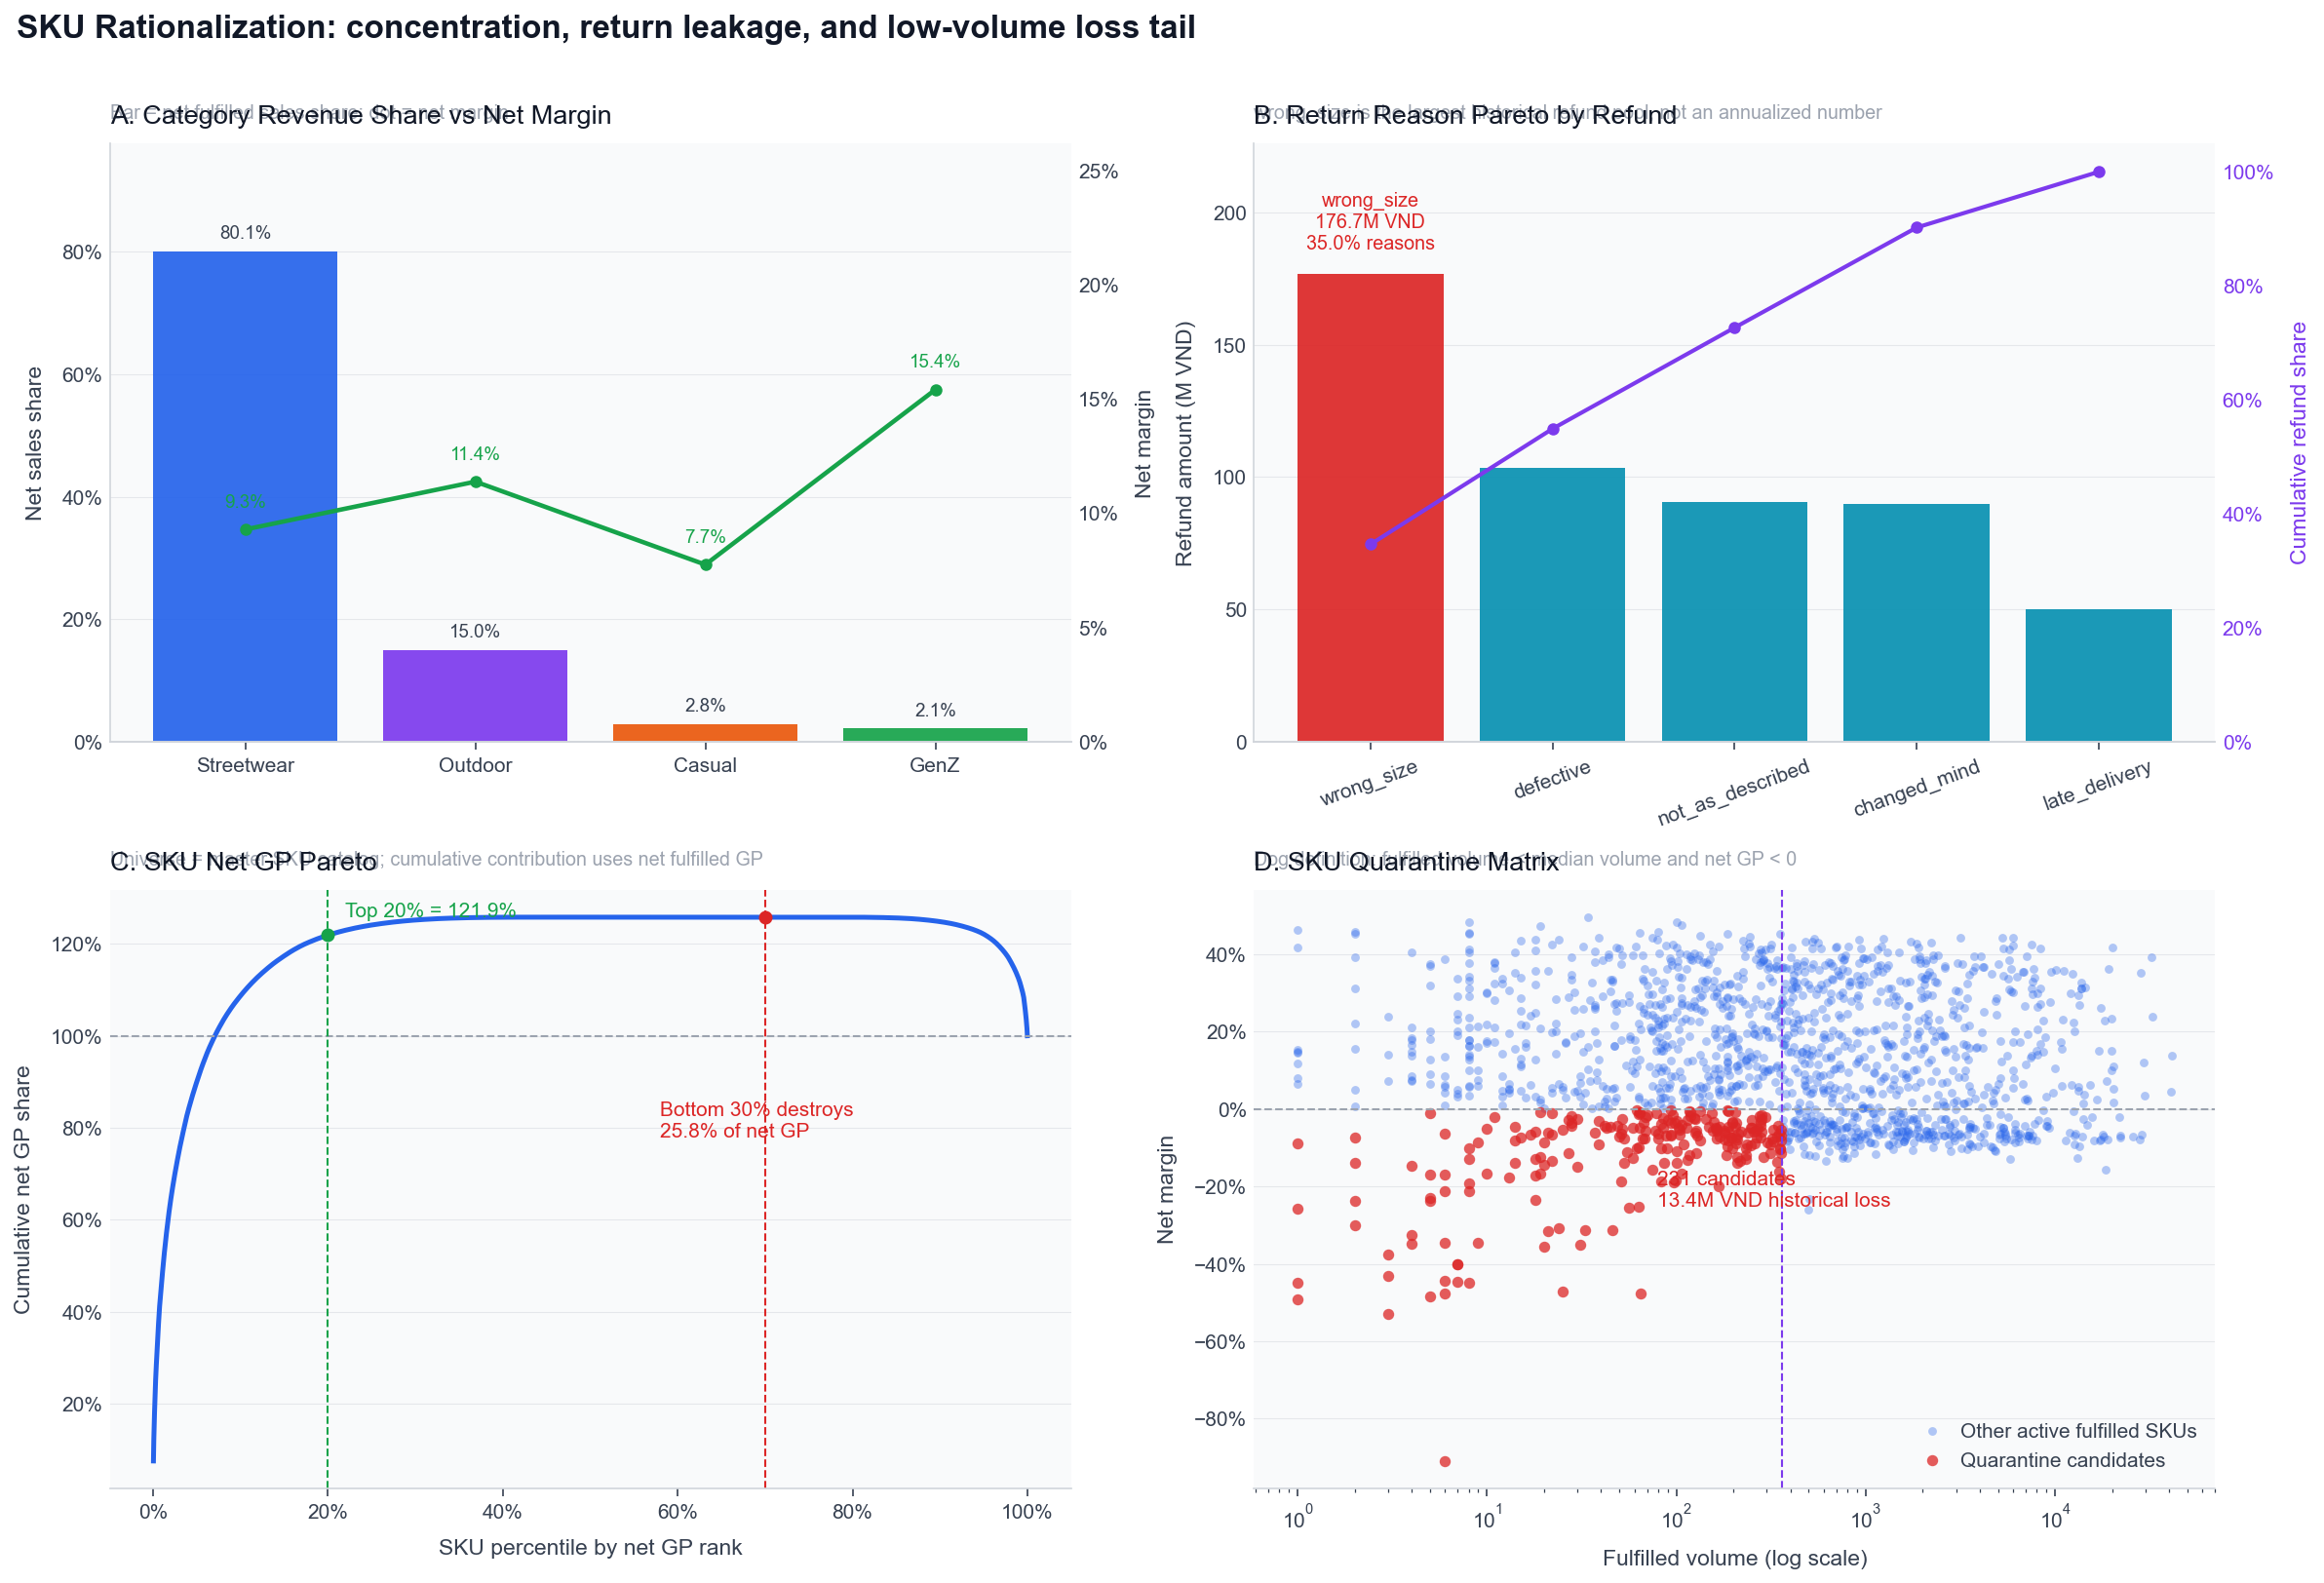

Saved: outputs\fig_sku_rationalization.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
ax_a, ax_b, ax_c, ax_d = axes.flatten()

# A. Category revenue share vs net margin.
cat_plot = category_perf.sort_values("net_sales_share", ascending=False).reset_index(drop=True)
x = np.arange(len(cat_plot))
bar_colors = colors_for(cat_plot["category"], known_map="category")
ax_a.bar(x, cat_plot["net_sales_share"], color=bar_colors, alpha=0.92)
ax_a.set_xticks(x)
ax_a.set_xticklabels(cat_plot["category"], rotation=0)
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_a.set_ylim(0, max(cat_plot["net_sales_share"].max() * 1.22, 0.2))
style_ax(
    ax_a,
    title="A. Category Revenue Share vs Net Margin",
    subtitle="Bar = net fulfilled sales share; dot = net margin",
    ylabel="Net sales share",
)
for i, row in cat_plot.iterrows():
    ax_a.text(i, row["net_sales_share"] + 0.015, fmt_pct(row["net_sales_share"], 1), ha="center", va="bottom", fontsize=9, color=CLR_LABEL)

ax_a2 = ax_a.twinx()
ax_a2.plot(x, cat_plot["net_margin_pct"], color=COLORS["emerald"], marker="o", linewidth=2.2)
ax_a2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_a2.set_ylim(0, max(cat_plot["net_margin_pct"].max() * 1.7, 0.2))
ax_a2.set_ylabel("Net margin")
ax_a2.grid(False)
for i, row in cat_plot.iterrows():
    ax_a2.text(i, row["net_margin_pct"] + 0.008, fmt_pct(row["net_margin_pct"], 1), ha="center", va="bottom", fontsize=9, color=COLORS["emerald"])

# B. Return reason Pareto by refund.
reason_plot = return_reason.sort_values("refund_amount", ascending=False).reset_index(drop=True)
reason_plot["cum_refund_share"] = reason_plot["refund_amount"].cumsum() / reason_plot["refund_amount"].sum()
reason_colors = [COLORS["red"] if r == "wrong_size" else COLORS["cyan"] for r in reason_plot["return_reason"]]
ax_b.bar(reason_plot["return_reason"], reason_plot["refund_amount"] / 1e6, color=reason_colors, alpha=0.92)
style_ax(
    ax_b,
    title="B. Return Reason Pareto by Refund",
    subtitle="wrong_size is the largest historical refund pool, not an annualized number",
    ylabel="Refund amount (M VND)",
)
ax_b.set_ylim(0, (reason_plot["refund_amount"].max() / 1e6) * 1.28)
ax_b.tick_params(axis="x", rotation=20)

ax_b2 = ax_b.twinx()
ax_b2.plot(reason_plot["return_reason"], reason_plot["cum_refund_share"], color=COLORS["violet"], marker="o", linewidth=2)
ax_b2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_b2.set_ylim(0, 1.05)
ax_b2.set_ylabel("Cumulative refund share")
ax_b2.tick_params(axis="y", colors=COLORS["violet"])
ax_b2.yaxis.label.set_color(COLORS["violet"])
ax_b2.grid(False)

wrong_idx = reason_plot.index[reason_plot["return_reason"].eq("wrong_size")][0]
wrong_refund_m = reason_plot.loc[wrong_idx, "refund_amount"] / 1e6
ax_b.text(
    wrong_idx,
    wrong_refund_m + 8,
    f"wrong_size\n{wrong_refund_m:,.1f}M VND\n{reason_plot.loc[wrong_idx, 'row_share']*100:.1f}% reasons",
    ha="center",
    va="bottom",
    fontsize=9.5,
    color=COLORS["red"],
    fontweight="medium",
)

# C. SKU Net GP Pareto.
ax_c.plot(sku_pareto["sku_percentile"], sku_pareto["cumulative_net_gp_share"], color=COLORS["blue"], linewidth=2.4)
ax_c.axhline(1.0, color=CLR_MUTED, linestyle="--", linewidth=1)
ax_c.axvline(0.20, color=COLORS["emerald"], linestyle="--", linewidth=1)
ax_c.axvline(0.70, color=COLORS["red"], linestyle="--", linewidth=1)
ax_c.scatter([0.20], [top_20_gp_share], color=COLORS["emerald"], s=45, zorder=3)
ax_c.scatter([0.70], [1 - bottom_30_gp_share], color=COLORS["red"], s=45, zorder=3)
ax_c.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_c.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
style_ax(
    ax_c,
    title="C. SKU Net GP Pareto",
    subtitle="Universe = master SKU catalog; cumulative contribution uses net fulfilled GP",
    xlabel="SKU percentile by net GP rank",
    ylabel="Cumulative net GP share",
)
ax_c.text(0.22, top_20_gp_share + 0.04, f"Top 20% = {top_20_gp_share*100:.1f}%", color=COLORS["emerald"], fontsize=10, fontweight="medium")
ax_c.text(0.58, 0.78, f"Bottom 30% destroys\n{abs(bottom_30_gp_share)*100:.1f}% of net GP", color=COLORS["red"], fontsize=10, fontweight="medium")

# D. SKU quarantine matrix.
matrix = sku_master.loc[sku_master["is_active_fulfilled"] & sku_master["net_margin_pct"].notna()].copy()
non_candidates = matrix.loc[~matrix["quarantine_candidate"]]
candidates = matrix.loc[matrix["quarantine_candidate"]]
ax_d.scatter(
    non_candidates["fulfilled_volume"],
    non_candidates["net_margin_pct"],
    s=18,
    color=COLORS["blue"],
    alpha=0.35,
    label="Other active fulfilled SKUs",
)
ax_d.scatter(
    candidates["fulfilled_volume"],
    candidates["net_margin_pct"],
    s=30,
    color=COLORS["red"],
    alpha=0.75,
    label="Quarantine candidates",
)
ax_d.axhline(0, color=CLR_MUTED, linestyle="--", linewidth=1)
ax_d.axvline(median_volume, color=COLORS["violet"], linestyle="--", linewidth=1)
ax_d.set_xscale("log")
ax_d.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
style_ax(
    ax_d,
    title="D. SKU Quarantine Matrix",
    subtitle="Dog definition: fulfilled volume < median volume and net GP < 0",
    xlabel="Fulfilled volume (log scale)",
    ylabel="Net margin",
)
ax_d.legend(loc="lower right")
ax_d.text(
    median_volume * 0.22,
    min(matrix["net_margin_pct"].quantile(0.03), -0.25),
    f"{len(candidates):,.0f} candidates\n{fmt_vnd_m(-candidates['net_gp'].sum())} historical loss",
    color=COLORS["red"],
    fontsize=10,
    fontweight="medium",
)

fig.suptitle("SKU Rationalization: concentration, return leakage, and low-volume loss tail", x=0.01, ha="left", fontsize=16, fontweight="bold", color=CLR_TITLE)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig_path = OUTPUT_DIR / "fig_sku_rationalization.png"
fig.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path.relative_to(ROOT)}")

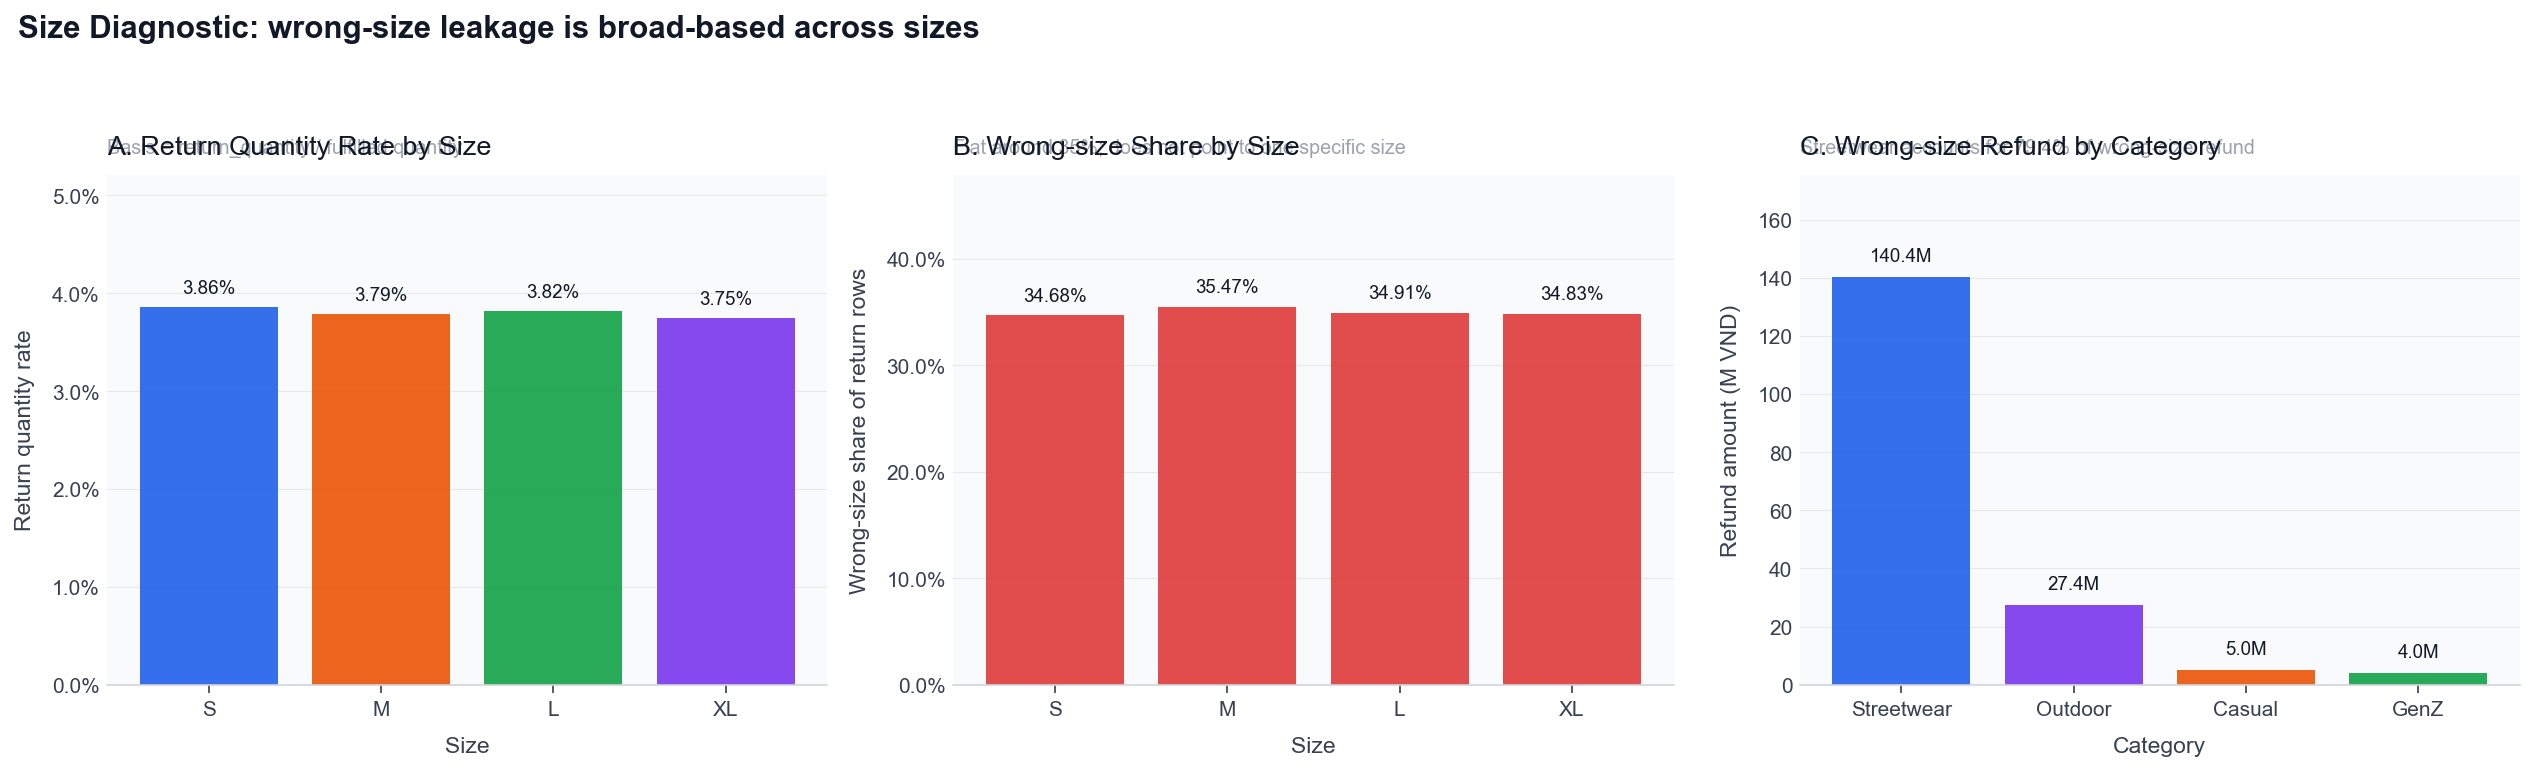

Saved: outputs\fig_sku_size_diagnostic.png


In [7]:
wrong_size_by_category = (
    returns_fulfilled.loc[returns_fulfilled["return_reason"].eq("wrong_size")]
    .groupby("category", as_index=False)
    .agg(return_rows=("return_id", "count"), return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
    .assign(refund_share=lambda d: d["refund_amount"] / d["refund_amount"].sum())
    .sort_values("refund_amount", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
ax_a, ax_b, ax_c = axes

size_plot = size_diag.reset_index().rename(columns={"index": "size"})
size_colors = colors_for(size_plot["size"], palette=get_palette(len(size_plot)))

ax_a.bar(size_plot["size"], size_plot["return_qty_rate"], color=size_colors, alpha=0.92)
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
style_ax(
    ax_a,
    title="A. Return Quantity Rate by Size",
    subtitle="Basis = return_quantity / fulfilled quantity",
    xlabel="Size",
    ylabel="Return quantity rate",
)
ax_a.set_ylim(0, size_plot["return_qty_rate"].max() * 1.35)
for i, row in size_plot.iterrows():
    ax_a.text(i, row["return_qty_rate"] + 0.001, fmt_pct(row["return_qty_rate"], 2), ha="center", va="bottom", fontsize=9)

ax_b.bar(size_plot["size"], size_plot["wrong_size_row_share"], color=[COLORS["red"]] * len(size_plot), alpha=0.82)
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
style_ax(
    ax_b,
    title="B. Wrong-size Share by Size",
    subtitle="Flat around 35%; does not point to one specific size",
    xlabel="Size",
    ylabel="Wrong-size share of return rows",
)
ax_b.set_ylim(0, size_plot["wrong_size_row_share"].max() * 1.35)
for i, row in size_plot.iterrows():
    ax_b.text(i, row["wrong_size_row_share"] + 0.01, fmt_pct(row["wrong_size_row_share"], 2), ha="center", va="bottom", fontsize=9)

cat_colors = colors_for(wrong_size_by_category["category"], known_map="category")
ax_c.bar(wrong_size_by_category["category"], wrong_size_by_category["refund_amount"] / 1e6, color=cat_colors, alpha=0.92)
style_ax(
    ax_c,
    title="C. Wrong-size Refund by Category",
    subtitle=f"Streetwear accounts for {wrong_size_by_category.iloc[0]['refund_share']*100:.1f}% of wrong-size refund",
    xlabel="Category",
    ylabel="Refund amount (M VND)",
)
ax_c.set_ylim(0, (wrong_size_by_category["refund_amount"] / 1e6).max() * 1.25)
for i, row in wrong_size_by_category.reset_index(drop=True).iterrows():
    ax_c.text(i, row["refund_amount"] / 1e6 + 4, f"{row['refund_amount']/1e6:,.1f}M", ha="center", va="bottom", fontsize=9)

fig.suptitle("Size Diagnostic: wrong-size leakage is broad-based across sizes", x=0.01, ha="left", fontsize=15, fontweight="bold", color=CLR_TITLE)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig_path = OUTPUT_DIR / "fig_sku_size_diagnostic.png"
fig.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path.relative_to(ROOT)}")

In [8]:
quarantine_export = quarantine_skus[
    [
        "product_id",
        "product_name",
        "category",
        "segment",
        "size",
        "fulfilled_volume",
        "net_sales",
        "net_gp",
        "net_margin_pct",
        "return_rows",
        "return_qty",
        "wrong_size_rows",
        "wrong_size_refund",
    ]
].sort_values("net_gp")
quarantine_path = OUTPUT_DIR / "sku_quarantine_candidates.csv"
quarantine_export.to_csv(quarantine_path, index=False)

wrong_size_refund = wrong_size_row["refund_amount"]
avoid_low = wrong_size_refund * 0.40
avoid_high = wrong_size_refund * 0.60
negative_reduction_target = int(np.ceil(len(negative_skus) * 0.25))

scenario_table = pd.DataFrame(
    [
        {
            "lever": "Fix size guide/filter",
            "evidence base": f"wrong_size refund pool = {fmt_vnd_m(wrong_size_refund)}",
            "scenario impact": f"Avoid {fmt_vnd_m(avoid_low)}\u2013{fmt_vnd_m(avoid_high)} of the 10-year historical refund pool if wrong-size returns fall 40\u201360% (not annualized)",
            "KPI target": f"Return rate {fmt_pct(return_rate_order_fulfilled)} \u2192 ~5.1%; wrong-size share {fmt_pct(wrong_size_row['row_share'], 1)} \u2192 <20%",
            "caveat": "Historical comparable base; requires UX/PDP size-guide test.",
        },
        {
            "lever": "Quarantine low-volume negative-GP SKUs",
            "evidence base": f"{len(quarantine_skus):,.0f} SKUs; volume < median {median_volume:,.0f}; net GP < 0",
            "scenario impact": f"Avoid {fmt_vnd_m(-quarantine_skus['net_gp'].sum())} historical loss pool on comparable base",
            "KPI target": f"Negative-GP SKU count -25% (~{negative_reduction_target:,.0f} SKUs)",
            "caveat": "Hide/quarantine before hard delist; monitor conversion and substitution.",
        },
        {
            "lever": "Catalog hygiene",
            "evidence base": f"{ghost_counts.get('ghost_fake', 0):,.0f} ghost_fake SKUs; threshold = 0.75 * active_min_price",
            "scenario impact": "Exclude ghost_fake from product and inventory analytics",
            "KPI target": "Cleaner SKU universe for dashboarding and inventory review",
            "caveat": "Keep ghost_real available for inventory diagnostics where relevant.",
        },
    ]
)

display(scenario_table)
print(f"Saved quarantine candidates: {quarantine_path.relative_to(ROOT)}")


,lever,evidence base,scenario impact,KPI target,caveat
0,Fix size guide/filter,wrong_size refund pool = 176.7M VND,Avoid 70.7M VND–106.0M VND of the 10-year hist...,Return rate 6.22% → ~5.1%; wrong-size share 35...,Historical comparable base; requires UX/PDP si...
1,Quarantine low-volume negative-GP SKUs,231 SKUs; volume < median 362; net GP < 0,Avoid 13.4M VND historical loss pool on compar...,Negative-GP SKU count -25% (~131 SKUs),Hide/quarantine before hard delist; monitor co...
2,Catalog hygiene,656 ghost_fake SKUs; threshold = 0.75 * active...,Exclude ghost_fake from product and inventory ...,Cleaner SKU universe for dashboarding and inve...,Keep ghost_real available for inventory diagno...


Saved quarantine candidates: outputs\sku_quarantine_candidates.csv


# Report Snippet

**Descriptive.** On a net fulfilled basis, the business generated 14.05B VND sales at 9.69% margin. Streetwear dominates the portfolio with 80.10% of net fulfilled sales but only 9.29% margin, while GenZ is small at 2.10% of sales and carries the highest margin at 15.41%. The catalog has 2,412 master SKUs, but only 1,581 active fulfilled SKUs; 814 SKUs are ghosts, including 656 ghost_fake records that should be excluded from product and inventory analytics.

**Diagnostic.** SKU economics are highly concentrated. The top 20% of master SKUs contribute 121.9% of net GP, while the bottom 30% destroys 25.8%. There are 521 negative-GP SKUs leaking 350.9M VND historically. Return leakage points to the same portfolio issue: wrong_size is the largest return reason at 35.0%, costing 176.7M VND in historical refunds. Size-level return quantity rates are almost flat across S/M/L/XL, and wrong-size share stays near 35%, so the evidence does not point to one specific size.

**Predictive.** If the current breadth remains unchanged, the long-tail SKU group is likely to keep diluting net GP and adding operational complexity. Because wrong-size leakage is broad-based across sizes and concentrated in Streetwear refund value, return pressure is more likely to persist as a fit-guidance and catalog-quality problem than as a single-size exception.

**Prescriptive.** Deploy category-size guidance and PDP filters first, targeting a 40–60% reduction in wrong-size returns on the comparable historical base, equivalent to 70.7–106.0M VND of avoidable refund pool (historical 2012–2022 comparable base, not annualized). Quarantine 231 low-volume negative-GP SKUs before hard delisting, monitor conversion, substitution, return rate, and net GP against a control group, and remove 656 ghost_fake SKUs from analytics. KPI targets: return rate 6.22% to about 5.1%, wrong-size share 35% to below 20%, and negative-GP SKU count down 25%.
